
Dataset loaded successfully.
Selected well for modeling: W26026

Building and training LSTM model...


Epoch 1/20

5/5 [==============================] - 11s 58ms/step - loss: 0.1070
Epoch 2/20
5/5 [==============================] - 0s 42ms/step - loss: 0.0154
Epoch 3/20
5/5 [==============================] - 0s 43ms/step - loss: 0.0037
Epoch 4/20
5/5 [==============================] - 0s 46ms/step - loss: 0.0071
Epoch 5/20
5/5 [==============================] - 0s 49ms/step - loss: 0.0019
Epoch 6/20
5/5 [==============================] - 0s 50ms/step - loss: 0.0016
Epoch 7/20
5/5 [==============================] - 0s 45ms/step - loss: 8.1111e-04
Epoch 8/20
5/5 [==============================] - 0s 49ms/step - loss: 4.7341e-04
Epoch 9/20
5/5 [==============================] - 0s 45ms/step - loss: 4.2910e-04
Epoch 10/20
5/5 [==============================] - 0s 48ms/step - loss: 1.0353e-04
Epoch 11/20
5/5 [==============================] - 0s 45ms/step - loss: 1.6848e-04
Epoch 12/20
5/

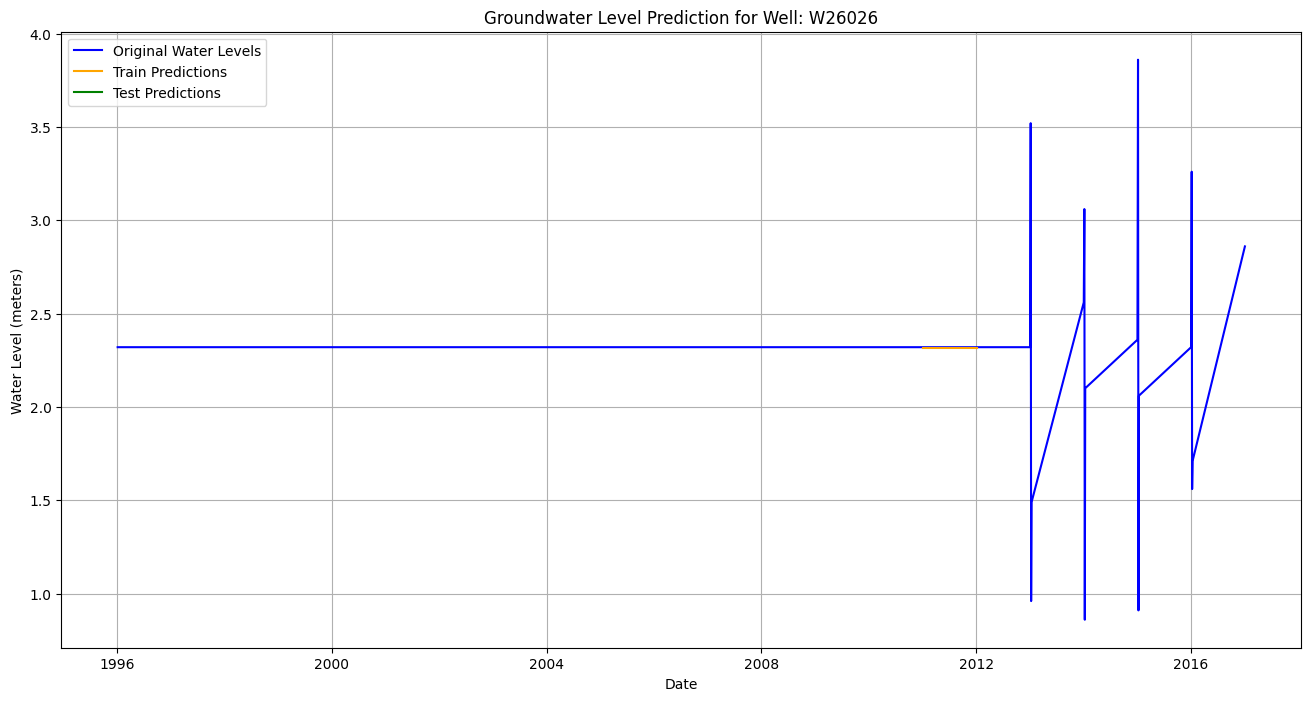

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# --- 1. Load and Preprocess the Data ---

# Load the dataset
try:
    df = pd.read_csv('CGWB_data_main_cleaned.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: CGWB_data_main_cleaned.csv not found. Please ensure the file is in the correct directory.")
    exit()

# Select the well with the most non-null values
well_data_counts = df.drop(columns=['STATE', 'DISTRICT', 'LAT', 'LON', 'SITE_TYPE', 'WLCODE']).notna().sum(axis=1)
best_well_index = well_data_counts.idxmax()
selected_well = df.iloc[[best_well_index]]
wlcode = selected_well['WLCODE'].iloc[0]
print(f"Selected well for modeling: {wlcode}")

# Melt the dataframe to transform it from wide to long format
id_vars = ['STATE', 'DISTRICT', 'LAT', 'LON', 'SITE_TYPE', 'WLCODE']
well_long = pd.melt(selected_well, id_vars=id_vars, var_name='Date', value_name='Water_Level')

# Convert 'Date' column to datetime objects
well_long['Date'] = pd.to_datetime(well_long['Date'], format='%d/%m/%Y', errors='coerce')
well_long = well_long.sort_values('Date')

# Handle missing values using forward fill
well_long['Water_Level'] = well_long['Water_Level'].ffill()
well_long = well_long.dropna(subset=['Water_Level'])  # Drop any remaining NaNs at the start

# Set the date as the index
well_long.set_index('Date', inplace=True)
water_levels = well_long[['Water_Level']]

# --- 2. Scale Data and Create Sequences ---

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(water_levels)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[0:train_size, :]
test_data = scaled_data[train_size - 60:, :]

def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        a = dataset[i:(i + time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# --- 3. Build and Train the LSTM Model ---

print("\nBuilding and training LSTM model...")
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, batch_size=1, epochs=20, verbose=1)
print("\nModel training complete.")

# --- 4. Make Predictions and Evaluate ---

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))

# --- PERFORMANCE EVALUATION ---
train_rmse = np.sqrt(mean_squared_error(y_train_inv, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict))
test_mae = mean_absolute_error(y_test_inv, test_predict)
train_r2 = r2_score(y_train_inv, train_predict)
test_r2 = r2_score(y_test_inv, test_predict)

print("\n--- Model Performance ---")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print("Note: Lower RMSE/MAE and higher R² values indicate a better model.")

# --- 5. Visualize the Results ---
plt.figure(figsize=(16, 8))
original_index = water_levels.index
plt.plot(original_index, water_levels['Water_Level'], label='Original Water Levels', color='blue')

train_predict_index = original_index[time_step:len(train_predict) + time_step]
plt.plot(train_predict_index, train_predict, label='Train Predictions', color='orange')

test_predict_index = original_index[len(train_predict) + (time_step*2) + 1 : len(scaled_data)-1]
min_len = min(len(test_predict_index), len(test_predict))
plt.plot(test_predict_index[:min_len], test_predict[:min_len], label='Test Predictions', color='green')

plt.title(f'Groundwater Level Prediction for Well: {wlcode}')
plt.xlabel('Date')
plt.ylabel('Water Level (meters)')
plt.legend()
plt.grid(True)

# Save the figure
output_file = "lstm_groundwater_prediction.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✅ Prediction plot saved as '{output_file}' (ready for download).")

plt.show()
